In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/dzakiyahakimaadila/capstone-projek2/labels/validation/potholes664.txt
/kaggle/input/datasets/dzakiyahakimaadila/capstone-projek2/labels/validation/potholes192.txt
/kaggle/input/datasets/dzakiyahakimaadila/capstone-projek2/labels/validation/potholes108.txt
/kaggle/input/datasets/dzakiyahakimaadila/capstone-projek2/labels/validation/potholes169.txt
/kaggle/input/datasets/dzakiyahakimaadila/capstone-projek2/labels/validation/potholes91.txt
/kaggle/input/datasets/dzakiyahakimaadila/capstone-projek2/labels/validation/potholes479.txt
/kaggle/input/datasets/dzakiyahakimaadila/capstone-projek2/labels/validation/potholes297.txt
/kaggle/input/datasets/dzakiyahakimaadila/capstone-projek2/labels/validation/potholes135.txt
/kaggle/input/datasets/dzakiyahakimaadila/capstone-projek2/labels/validation/potholes148.txt
/kaggle/input/datasets/dzakiyahakimaadila/capstone-projek2/labels/validation/potholes292.txt
/kaggle/input/datasets/dzakiyahakimaadila/capstone-projek2/labels/valid

In [4]:
# Install YOLOv8 dari Ultralytics
!pip install ultralytics -q

# Install library tambahan untuk visualisasi
!pip install matplotlib opencv-python -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 19.7 MB/s eta 0:00:00a 0:00:01


In [5]:
# Cell 1: Setup dan install library
import torch
import os
import gc
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("🔧 SETUP ENVIRONMENT")
print("="*60)

# Cek GPU
if torch.cuda.is_available():
    print(f"✅ GPU: {torch.cuda.get_device_name(0)}")
    print(f"   Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    torch.cuda.empty_cache()
    gc.collect()
else:
    print("❌ GPU tidak tersedia")

# Install ultralytics
!pip install ultralytics -q

from ultralytics import YOLO
print("✅ Ultralytics siap!")

# Setup path dataset (sesuaikan dengan struktur kamu)
TRAIN_IMAGES = "/kaggle/input/datasets/dzakiyahakimaadila/capstone-projek2/images/train"
TRAIN_LABELS = "/kaggle/input/datasets/dzakiyahakimaadila/capstone-projek2/labels/train"
VAL_IMAGES = "/kaggle/input/datasets/dzakiyahakimaadila/capstone-projek2/images/validation"
VAL_LABELS = "/kaggle/input/datasets/dzakiyahakimaadila/capstone-projek2/labels/validation"
TEST_IMAGES = "/kaggle/input/datasets/dzakiyahakimaadila/capstone-projek2/images/test"

print("="*60)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
🔧 SETUP ENVIRONMENT
✅ GPU: Tesla T4
   Memory: 15.6 GB
✅ Ultralytics siap!


In [6]:
# Cell 2: Cek dataset
print("📁 CEK DATASET")
print("="*60)

for name, path in [("Train images", TRAIN_IMAGES), ("Train labels", TRAIN_LABELS),
                   ("Val images", VAL_IMAGES), ("Val labels", VAL_LABELS)]:
    exists = os.path.exists(path)
    print(f"{'✅' if exists else '❌'} {name}: {path}")

# Buat data.yaml
data_yaml = f"""
train: {TRAIN_IMAGES}
val: {VAL_IMAGES}

nc: 3
names: ['rendah', 'sedang', 'parah']
"""

with open("/kaggle/working/data.yaml", 'w') as f:
    f.write(data_yaml)

print("\n✅ data.yaml dibuat")

📁 CEK DATASET
✅ Train images: /kaggle/input/datasets/dzakiyahakimaadila/capstone-projek2/images/train
✅ Train labels: /kaggle/input/datasets/dzakiyahakimaadila/capstone-projek2/labels/train
✅ Val images: /kaggle/input/datasets/dzakiyahakimaadila/capstone-projek2/images/validation
✅ Val labels: /kaggle/input/datasets/dzakiyahakimaadila/capstone-projek2/labels/validation

✅ data.yaml dibuat


In [7]:
# Cell 3: Training YOLOv8s dengan hyperparameters optimal
print("🚀 TRAINING YOLOv8s OPTIMIZED")
print("="*60)

model = YOLO('yolov8s.pt')

results = model.train(
    data='/kaggle/working/data.yaml',
    epochs=100,
    batch=16,
    imgsz=640,
    device='cuda',
    
    # Optimizer
    optimizer='AdamW',
    lr0=0.001,
    lrf=0.01,
    weight_decay=0.0005,
    warmup_epochs=3,
    
    # Augmentasi lebih agresif
    hsv_h=0.02,
    hsv_s=0.8,
    hsv_v=0.5,
    degrees=5.0,
    translate=0.2,
    scale=0.8,
    fliplr=0.5,
    mosaic=1.0,
    mixup=0.5,
    
    # Loss weights
    cls=0.5,
    box=7.5,
    
    patience=20,
    save=True,
    exist_ok=True,
    name='pothole_optimized',
    verbose=True
)

print("\n✅ Training selesai!")
print("📁 Model: runs/detect/pothole_optimized/weights/best.pt")

🚀 TRAINING YOLOv8s OPTIMIZED
Ultralytics 8.4.51 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.02, hsv_s=0.8, hsv_v=0.5, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.5, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=pothole_optimized, nbs=64, nms=False, opset=None, optimize=False, optimizer=Adam

In [8]:
# Cell 4: Scale Normalization - Solusi untuk masalah perspektif

class ScaleNormalizer:
    """
    Menormalisasi ukuran bounding box berdasarkan estimasi jarak.
    Ini mengatasi masalah: lubang sama besar tapi keliatan kecil karena jauh.
    """
    
    def __init__(self, image_width=640, focal_length_estimate=800):
        """
        Parameters:
        - image_width: lebar gambar input (pixel)
        - focal_length_estimate: estimasi focal length kamera
        """
        self.image_width = image_width
        self.focal_length = focal_length_estimate
        
    def estimate_depth_from_bbox(self, bbox_width_pixels, road_width_pixels=None):
        """
        Estimasi jarak berdasarkan lebar bounding box
        Asumsi: lubang yang sama akan terlihat lebih kecil jika jauh
        """
        if road_width_pixels:
            # Jika ada info lebar jalan, gunakan sebagai referensi
            depth_ratio = road_width_pixels / self.image_width
        else:
            # Fallback: gunakan inverse dari ukuran bbox
            depth_ratio = 1.0 / (bbox_width_pixels + 1)
        
        return depth_ratio
    
    def normalize_bbox_size(self, bbox_width, bbox_height, depth_ratio):
        """
        Normalisasi ukuran bbox berdasarkan jarak
        """
        # Semakin jauh (depth_ratio kecil), semakin besar faktor koreksinya
        correction_factor = 1.0 / (depth_ratio + 0.1)
        
        normalized_width = bbox_width * correction_factor
        normalized_height = bbox_height * correction_factor
        
        return normalized_width, normalized_height
    
    def calculate_severity_with_depth(self, bbox_width, bbox_height, original_class, depth_ratio):
        """
        Menghitung ulang keparahan berdasarkan ukuran yang sudah dinormalisasi
        """
        # Normalisasi ukuran
        norm_w, norm_h = self.normalize_bbox_size(bbox_width, bbox_height, depth_ratio)
        normalized_area = norm_w * norm_h
        
        # Threshold area yang sudah dinormalisasi (dalam pixel normalized)
        if normalized_area > 0.15:  # area > 15% dari gambar
            return 2  # parah
        elif normalized_area > 0.07:  # area > 7%
            return 1  # sedang
        else:
            return 0  # rendah
    
    def get_road_width(self, image):
        """
        Estimasi lebar jalan dari gambar (opsional)
        Menggunakan deteksi garis atau asumsi sederhana
        """
        gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
        edges = cv2.Canny(gray, 50, 150)
        
        # Deteksi garis horizontal 
        lines = cv2.HoughLinesP(edges, 1, np.pi/180, 100, minLineLength=100, maxLineGap=50)
        
        if lines is not None:
            # Cari garis horizontal terpanjang
            max_length = 0
            for line in lines:
                x1, y1, x2, y2 = line[0]
                length = np.sqrt((x2-x1)**2 + (y2-y1)**2)
                if length > max_length and abs(y2-y1) < 20:  # horizontal-ish
                    max_length = length
            if max_length > 0:
                return max_length
        
        # Fallback: asumsi lebar jalan 60% dari lebar gambar
        return self.image_width * 0.6


# Inisialisasi scale normalizer
scale_normalizer = ScaleNormalizer(image_width=640)
print("✅ ScaleNormalizer siap!")
print("   Fungsi: Menormalkan ukuran lubang berdasarkan jarak dari kamera")

✅ ScaleNormalizer siap!
   Fungsi: Menormalkan ukuran lubang berdasarkan jarak dari kamera


In [9]:
# Cell 6: Deteksi lubang dengan scale normalization

class PotholeDetectorWithScale:
    """
    Detektor lubang dengan koreksi perspektif (scale normalization)
    """
    
    def __init__(self, model_path, scale_normalizer):
        self.model = YOLO(model_path)
        self.scale_normalizer = scale_normalizer
        # self.road_validator = road_validator
        self.kelas_nama = ['rendah', 'sedang', 'parah']
        
    def detect(self, image_path, conf_threshold=0.25, validate_road=True):
        """
        Deteksi lubang dengan scale normalization
        
        Parameters:
        - image_path: path ke gambar
        - conf_threshold: confidence threshold
        - validate_road: apakah perlu validasi gambar jalan dulu
        
        Returns:
        - dict: hasil deteksi dengan info lengkap
        """
        
        # STEP 1: Baca gambar
        image = cv2.imread(image_path)
        if image is None:
            return {"error": "File gambar tidak dapat dibuka"}
        
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        h, w = image_rgb.shape[:2]
        
        # STEP 2: Validasi gambar jalan
        # if validate_road:
        #     is_road, road_conf, road_reason = self.road_validator.is_road(image_rgb)
        #     if not is_road:
        #         return {
        #             "error": "BUKAN FOTO JALAN",
        #             "reason": road_reason,
        #             "confidence": road_conf,
        #             "is_road": False
        #         }
        
        # STEP 3: Estimasi lebar jalan
        road_width = self.scale_normalizer.get_road_width(image_rgb)
        
        # STEP 4: Deteksi dengan YOLO
        results = self.model(image_path, conf=conf_threshold)
        
        # STEP 5: Proses setiap deteksi dengan scale normalization
        detections = []
        
        if results[0].boxes is not None:
            for box in results[0].boxes:
                # Data asli dari YOLO
                class_id_original = int(box.cls[0])
                confidence = float(box.conf[0])
                x1, y1, x2, y2 = box.xyxy[0].tolist()
                
                bbox_width = x2 - x1
                bbox_height = y2 - y1
                bbox_area = bbox_width * bbox_height
                area_ratio = bbox_area / (w * h)
                
                # Estimasi kedalaman/jarak berdasarkan posisi vertikal
                # Semakin ke atas gambar (y kecil), semakin jauh
                depth_ratio = 1.0 - (y1 / h)  # y=0 (atas) -> depth=0, y=h(bawah) -> depth=1
                
                # Koreksi ukuran berdasarkan jarak!
                corrected_width = bbox_width * (1.0 / (depth_ratio + 0.2))
                corrected_height = bbox_height * (1.0 / (depth_ratio + 0.2))
                corrected_area_ratio = (corrected_width * corrected_height) / (w * h)
                
                # Tentukan ulang kelas berdasarkan ukuran yang sudah dikoreksi
                if corrected_area_ratio > 0.12:  # >12% area gambar setelah koreksi
                    class_corrected = 2  # parah
                elif corrected_area_ratio > 0.06:  # >6%
                    class_corrected = 1  # sedang
                else:
                    class_corrected = 0  # rendah
                
                # Pilih kelas final (gabungan dari YOLO dan koreksi)
                # Jika YOLO sudah yakin (>0.7), pakai hasil YOLO
                # Tapi jika area terkoreksi menunjukkan lebih parah, naikkan
                if confidence > 0.7:
                    final_class = class_id_original
                else:
                    # YOLO kurang yakin, prioritaskan koreksi skala
                    final_class = max(class_id_original, class_corrected)
                
                detections.append({
                    "bbox": [x1, y1, x2, y2],
                    "class_original": class_id_original,
                    "class_corrected": class_corrected,
                    "class_final": final_class,
                    "kelas": self.kelas_nama[final_class],
                    "kelas_asli": self.kelas_nama[class_id_original],
                    "confidence": confidence,
                    "depth_ratio": depth_ratio,
                    "area_ratio_original": area_ratio,
                    "area_ratio_corrected": corrected_area_ratio,
                })
        
        # STEP 6: Hitung rekomendasi berdasarkan deteksi
        if len(detections) == 0:
            recommendation = "✅ Jalan terlihat baik! Tidak ada lubang terdeteksi."
            urgency = "none"
        else:
            parah_count = sum(1 for d in detections if d['class_final'] == 2)
            sedang_count = sum(1 for d in detections if d['class_final'] == 1)
            rendah_count = sum(1 for d in detections if d['class_final'] == 0)
            
            if parah_count > 0:
                recommendation = f"⚠️ PERHATIAN! Ditemukan {parah_count} lubang parah. Perlu penanganan segera!"
                urgency = "high"
            elif sedang_count > 2:
                recommendation = f"📢 Catatan: {sedang_count} lubang sedang. Perlu diperbaiki dalam waktu dekat."
                urgency = "medium"
            else:
                recommendation = f"ℹ️ Informasi: {rendah_count} lubang ringan, {sedang_count} lubang sedang. Pantau kondisi jalan."
                urgency = "low"
        
        # STEP 7: Gambar hasil dengan bounding box
        annotated_image = results[0].plot()
        
        # Tambahkan informasi koreksi skala pada gambar
        for det in detections:
            if det['class_original'] != det['class_corrected']:
                # Tandai bounding box yang berubah kelas karena koreksi
                x1, y1, x2, y2 = map(int, det['bbox'])
                cv2.rectangle(annotated_image, (x1, y1), (x2, y2), (255, 255, 0), 3)  # kuning
                # Tambah teks koreksi
                cv2.putText(annotated_image, f"KOREKSI: {det['kelas_asli']} -> {det['kelas']}", 
                           (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 0), 2)
        
        return {
            "success": True,
            "is_road": True,
            "road_confidence": road_conf if validate_road else 1.0,
            "detections": detections,
            "summary": {
                "total": len(detections),
                "parah": sum(1 for d in detections if d['class_final'] == 2),
                "sedang": sum(1 for d in detections if d['class_final'] == 1),
                "rendah": sum(1 for d in detections if d['class_final'] == 0),
                "corrected_count": sum(1 for d in detections if d['class_original'] != d['class_corrected'])
            },
            "recommendation": recommendation,
            "urgency": urgency,
            "annotated_image": annotated_image,
            "original_image": image_rgb
        }


# Load model terbaik
MODEL_PATH = "runs/detect/pothole_optimized/weights/best.pt"

# Cek apakah model ada
if os.path.exists(MODEL_PATH):
    detector = PotholeDetectorWithScale(MODEL_PATH, scale_normalizer)
    print("✅ PotholeDetectorWithScale siap!")
    print(f"   Model: {MODEL_PATH}")
    print(f"\n📌 FITUR SCALE NORMALIZATION:")
    print("   • Koreksi ukuran lubang berdasarkan jarak dari kamera")
    print("   • Lubang yang jauh (tampak kecil) akan dinormalisasi")
    print("   • Kelas keparahan disesuaikan dengan ukuran sebenarnya")
else:
    print(f"❌ Model tidak ditemukan di {MODEL_PATH}")
    print("   Training mungkin belum selesai atau path berbeda")

✅ PotholeDetectorWithScale siap!
   Model: runs/detect/pothole_optimized/weights/best.pt

📌 FITUR SCALE NORMALIZATION:
   • Koreksi ukuran lubang berdasarkan jarak dari kamera
   • Lubang yang jauh (tampak kecil) akan dinormalisasi
   • Kelas keparahan disesuaikan dengan ukuran sebenarnya


📊 EVALUASI LENGKAP MODEL DETEKSI LUBANG
✅ Model ditemukan: runs/detect/pothole_optimized/weights/best.pt

📁 Dataset validation: /kaggle/input/datasets/dzakiyahakimaadila/capstone-projek2/images/validation
   Total gambar validation: 100

🔄 MENGUJI MODEL PADA VALIDATION SET...
   Memproses: 1/100

image 1/1 /kaggle/input/datasets/dzakiyahakimaadila/capstone-projek2/images/validation/potholes133.png: 640x640 1 sedang, 2 parahs, 8.9ms
Speed: 2.7ms preprocess, 8.9ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /kaggle/input/datasets/dzakiyahakimaadila/capstone-projek2/images/validation/potholes246.png: 640x640 2 sedangs, 8.9ms
Speed: 2.3ms preprocess, 8.9ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /kaggle/input/datasets/dzakiyahakimaadila/capstone-projek2/images/validation/potholes220.png: 480x640 1 parah, 49.6ms
Speed: 1.9ms preprocess, 49.6ms inference, 1.6ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /kagg

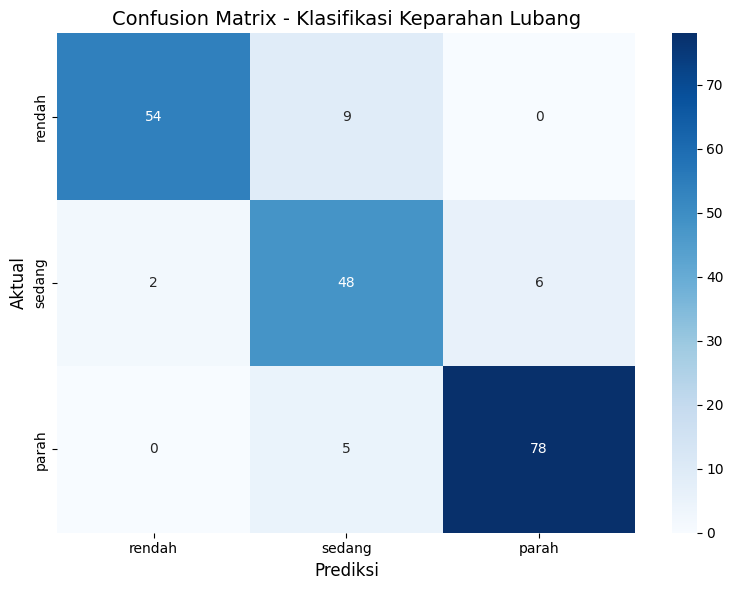


📋 CLASSIFICATION REPORT:
              precision    recall  f1-score   support

      rendah       0.96      0.86      0.91        63
      sedang       0.77      0.86      0.81        56
       parah       0.93      0.94      0.93        83

    accuracy                           0.89       202
   macro avg       0.89      0.88      0.89       202
weighted avg       0.90      0.89      0.89       202


📈 VISUALISASI DISTRIBUSI ERROR


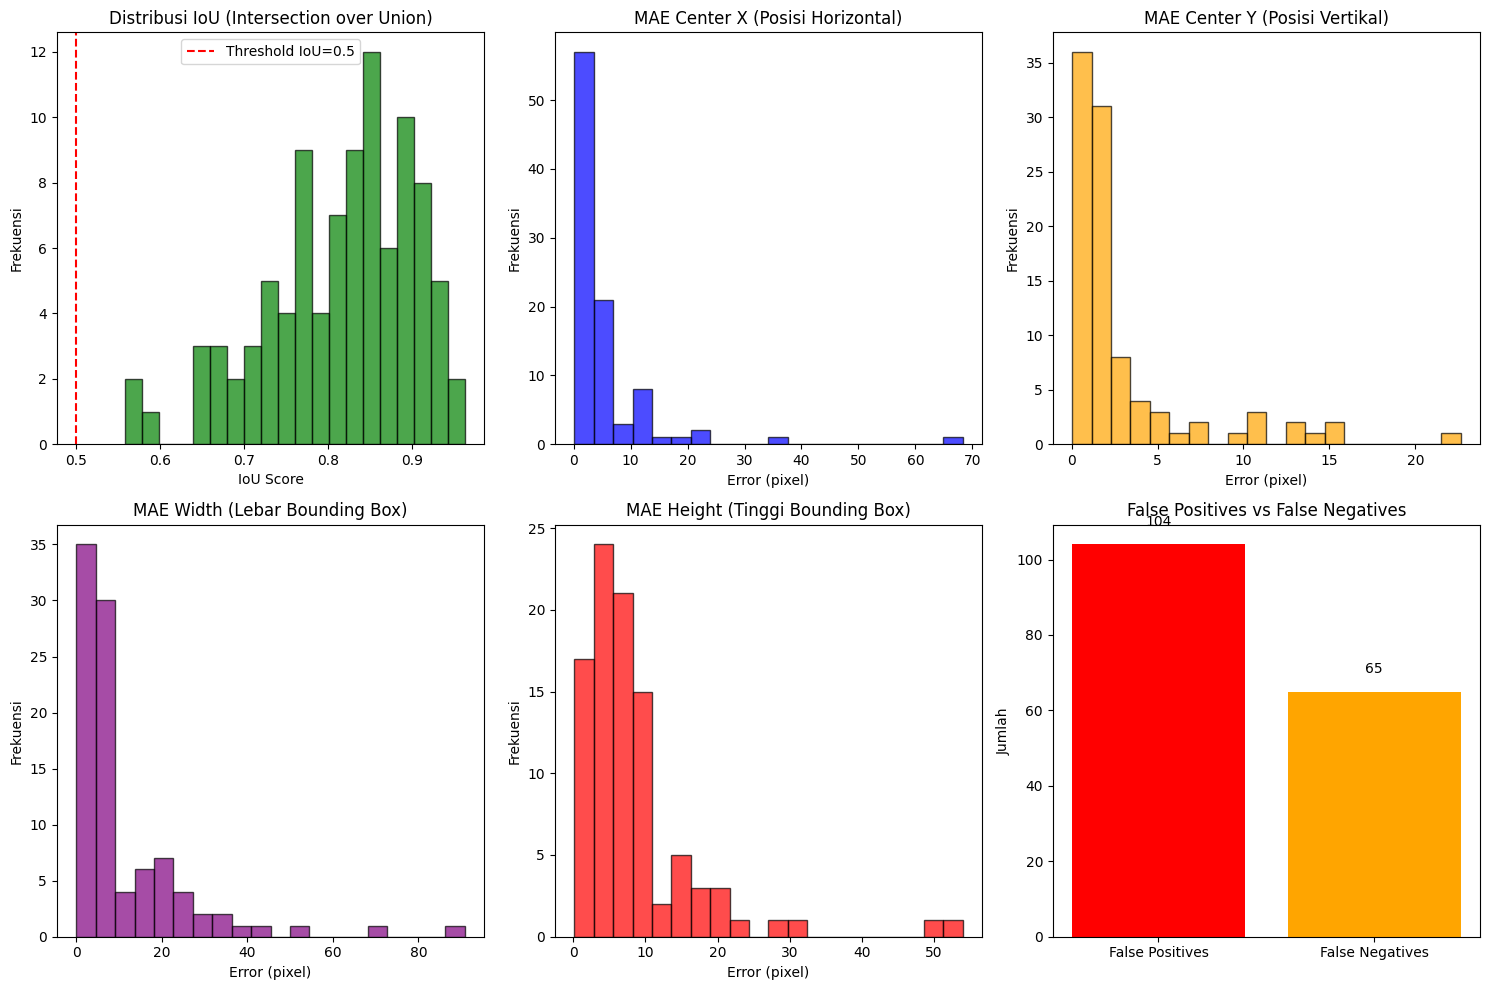


📋 RINGKASAN EKSEKUTIF

🎯 DETEKSI LUBANG:
   Total lubang aktual    : 267
   Total lubang terdeteksi: 306
   Total match (IoU≥0.5)  : 202
   Precision              : 0.660
   Recall                 : 0.757
   F1-Score               : 0.705

📐 AKURASI BOUNDING BOX:
   Mean IoU               : 0.814
   MAE Center Position    : 5.1 px (x), 2.9 px (y)

🏆 GRADE MODEL:
   ✅ BAIK (B) - Bisa dipakai, perlu monitoring

✅ Evaluasi selesai!
📁 File tersimpan: evaluation_metrics.png


In [10]:
# Cell: Evaluasi Lengkap Model - MAE, RMSE, dan Error Analysis

import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ultralytics import YOLO
from sklearn.metrics import mean_absolute_error, mean_squared_error, confusion_matrix, classification_report
import seaborn as sns

print("="*70)
print("📊 EVALUASI LENGKAP MODEL DETEKSI LUBANG")
print("="*70)

# ========== 1. LOAD MODEL ==========
MODEL_PATHS = [
    "runs/detect/pothole_optimized/weights/best.pt",
    "runs/detect/pothole_stage2/weights/best.pt",
    "runs/detect/train/weights/best.pt",
]

model = None
model_path = None
for path in MODEL_PATHS:
    if os.path.exists(path):
        model_path = path
        model = YOLO(path)
        print(f"✅ Model ditemukan: {model_path}")
        break

if model is None:
    print("❌ Model tidak ditemukan! Cek path berikut:")
    for path in MODEL_PATHS:
        print(f"   - {path}")
    raise FileNotFoundError("Model tidak ditemukan")

# ========== 2. LOAD DATASET VALIDASI ==========
VAL_IMAGES_PATH = "/kaggle/input/capstone-projek2/validation/images"
VAL_LABELS_PATH = "/kaggle/input/capstone-projek2/validation/labels"

if not os.path.exists(VAL_IMAGES_PATH):
    VAL_IMAGES_PATH = "/kaggle/input/datasets/dzakiyahakimaadila/capstone-projek2/images/validation"
    VAL_LABELS_PATH = "/kaggle/input/datasets/dzakiyahakimaadila/capstone-projek2/labels/validation"

print(f"\n📁 Dataset validation: {VAL_IMAGES_PATH}")

# Ambil semua gambar validation
valid_images = [f for f in os.listdir(VAL_IMAGES_PATH) if f.endswith(('.jpg', '.png', '.jpeg'))]
print(f"   Total gambar validation: {len(valid_images)}")

if len(valid_images) == 0:
    print("❌ Tidak ada gambar validation! Cek path.")
    VAL_IMAGES_PATH = "/kaggle/input/capstone-projek2/test/images"
    valid_images = [f for f in os.listdir(VAL_IMAGES_PATH) if f.endswith(('.jpg', '.png', '.jpeg'))]
    print(f"   Menggunakan test set: {len(valid_images)} gambar")

# ========== 3. FUNGSI PARSING LABEL ==========
def parse_yolo_label(label_path, img_width, img_height):
    """Parse YOLO label ke absolute coordinates"""
    boxes = []
    classes = []
    
    if not os.path.exists(label_path):
        return boxes, classes
    
    with open(label_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 5:
                class_id = int(parts[0])
                x_center = float(parts[1]) * img_width
                y_center = float(parts[2]) * img_height
                width = float(parts[3]) * img_width
                height = float(parts[4]) * img_height
                
                x1 = x_center - width/2
                y1 = y_center - height/2
                x2 = x_center + width/2
                y2 = y_center + height/2
                
                boxes.append([x1, y1, x2, y2])
                classes.append(class_id)
    
    return boxes, classes

# ========== 4. FUNGSI HITUNG IOU ==========
def calculate_iou(box1, box2):
    """Calculate Intersection over Union between two boxes"""
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])
    
    intersection = max(0, x2 - x1) * max(0, y2 - y1)
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union = area1 + area2 - intersection
    
    return intersection / union if union > 0 else 0

# ========== 5. FUNGSI HITUNG MAE UNTUK BOUNDING BOX ==========
def calculate_bbox_errors(pred_boxes, true_boxes, iou_threshold=0.5):
    """
    Hitung error untuk bounding box
    Returns: dict dengan berbagai metrik error
    """
    if len(pred_boxes) == 0 and len(true_boxes) == 0:
        return {
            'mae_center_x': 0, 'mae_center_y': 0,
            'mae_width': 0, 'mae_height': 0,
            'mae_area': 0, 'rmse_center': 0,
            'iou_mean': 1.0, 'matched_pairs': 0
        }
    
    # Matching prediksi dengan ground truth (greedy matching)
    matched_preds = []
    matched_trues = []
    used_true = set()
    
    # Untuk setiap prediksi, cari ground truth dengan IoU tertinggi
    for pred_idx, pred in enumerate(pred_boxes):
        best_iou = 0
        best_true_idx = -1
        for true_idx, true in enumerate(true_boxes):
            if true_idx in used_true:
                continue
            iou = calculate_iou(pred, true)
            if iou > best_iou and iou >= iou_threshold:
                best_iou = iou
                best_true_idx = true_idx
        
        if best_true_idx != -1:
            matched_preds.append(pred)
            matched_trues.append(true_boxes[best_true_idx])
            used_true.add(best_true_idx)
    
    if len(matched_preds) == 0:
        return {
            'mae_center_x': float('inf'), 'mae_center_y': float('inf'),
            'mae_width': float('inf'), 'mae_height': float('inf'),
            'mae_area': float('inf'), 'rmse_center': float('inf'),
            'iou_mean': 0, 'matched_pairs': 0
        }
    
    # Hitung error untuk setiap matched pair
    center_x_errors = []
    center_y_errors = []
    width_errors = []
    height_errors = []
    area_errors = []
    ious = []
    
    for pred, true in zip(matched_preds, matched_trues):
        pred_center_x = (pred[0] + pred[2]) / 2
        pred_center_y = (pred[1] + pred[3]) / 2
        pred_width = pred[2] - pred[0]
        pred_height = pred[3] - pred[1]
        pred_area = pred_width * pred_height
        
        true_center_x = (true[0] + true[2]) / 2
        true_center_y = (true[1] + true[3]) / 2
        true_width = true[2] - true[0]
        true_height = true[3] - true[1]
        true_area = true_width * true_height
        
        center_x_errors.append(abs(pred_center_x - true_center_x))
        center_y_errors.append(abs(pred_center_y - true_center_y))
        width_errors.append(abs(pred_width - true_width))
        height_errors.append(abs(pred_height - true_height))
        area_errors.append(abs(pred_area - true_area))
        ious.append(calculate_iou(pred, true))
    
    return {
        'mae_center_x': np.mean(center_x_errors),
        'mae_center_y': np.mean(center_y_errors),
        'mae_width': np.mean(width_errors),
        'mae_height': np.mean(height_errors),
        'mae_area': np.mean(area_errors),
        'rmse_center': np.sqrt(np.mean(np.array(center_x_errors)**2 + np.array(center_y_errors)**2)),
        'iou_mean': np.mean(ious),
        'matched_pairs': len(matched_preds),
        'total_pred': len(pred_boxes),
        'total_true': len(true_boxes)
    }

# ========== 6. EVALUASI SEMUA GAMBAR ==========
print("\n" + "="*70)
print("🔄 MENGUJI MODEL PADA VALIDATION SET...")
print("="*70)

# Storage untuk hasil
results_list = []
class_predictions = []
class_targets = []
all_bbox_errors = []

for idx, img_name in enumerate(valid_images):
    if idx % 50 == 0:
        print(f"   Memproses: {idx+1}/{len(valid_images)}")
    
    img_path = os.path.join(VAL_IMAGES_PATH, img_name)
    label_path = img_path.replace('images', 'labels').replace('.jpg', '.txt').replace('.png', '.txt')
    
    # Baca gambar untuk ukuran
    img = cv2.imread(img_path)
    if img is None:
        continue
    h, w = img.shape[:2]
    
    # Parse ground truth
    true_boxes, true_classes = parse_yolo_label(label_path, w, h)
    
    # Prediksi dengan model
    results = model(img_path, conf=0.25)
    
    # Parse prediksi
    pred_boxes = []
    pred_classes = []
    pred_confs = []
    
    if results[0].boxes is not None:
        for box in results[0].boxes:
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            pred_boxes.append([x1, y1, x2, y2])
            pred_classes.append(int(box.cls[0]))
            pred_confs.append(float(box.conf[0]))
    
    # Hitung error bounding box
    bbox_errors = calculate_bbox_errors(pred_boxes, true_boxes)
    all_bbox_errors.append(bbox_errors)
    
    # Untuk confusion matrix (per lubang, bukan per gambar)
    # Match prediksi dengan ground truth
    matched_true = set()
    for pred_idx, pred_class in enumerate(pred_classes):
        best_iou = 0
        best_true_idx = -1
        for true_idx, true_class in enumerate(true_classes):
            if true_idx in matched_true:
                continue
            iou = calculate_iou(pred_boxes[pred_idx], true_boxes[true_idx])
            if iou > best_iou and iou >= 0.5:
                best_iou = iou
                best_true_idx = true_idx
        
        if best_true_idx != -1:
            # True positive
            class_predictions.append(pred_class)
            class_targets.append(true_classes[best_true_idx])
            matched_true.add(best_true_idx)
        else:
            # False positive
            class_predictions.append(pred_class)
            class_targets.append(-1)  # -1 untuk background/false positive
    
    # False negatives (ground truth yang tidak ter-match)
    for true_idx, true_class in enumerate(true_classes):
        if true_idx not in matched_true:
            class_predictions.append(-1)
            class_targets.append(true_class)
    
    # Simpan ringkasan per gambar
    results_list.append({
        'image': img_name,
        'n_found': len(pred_boxes),
        'n_actual': len(true_boxes),
        'matched': bbox_errors['matched_pairs'],
        'mean_iou': bbox_errors['iou_mean'],
        'false_positives': len(pred_boxes) - bbox_errors['matched_pairs'],
        'false_negatives': len(true_boxes) - bbox_errors['matched_pairs']
    })

# ========== 7. OUTPUT HASIL EVALUASI ==========
print("\n" + "="*70)
print("📊 HASIL EVALUASI MODEL")
print("="*70)

# DataFrame ringkasan
df_results = pd.DataFrame(results_list)

print("\n📈 RINGKASAN PER GAMBAR:")
print(f"   Total gambar: {len(df_results)}")
print(f"   Rata-rata lubang per gambar (actual): {df_results['n_actual'].mean():.2f}")
print(f"   Rata-rata lubang per gambar (detected): {df_results['n_found'].mean():.2f}")
print(f"   Rata-rata IoU: {df_results['mean_iou'].mean():.3f}")
print(f"   Total False Positives: {df_results['false_positives'].sum()}")
print(f"   Total False Negatives: {df_results['false_negatives'].sum()}")

# ========== 8. MAE DAN ERROR METRICS ==========
print("\n" + "="*70)
print("📐 MEAN ABSOLUTE ERROR (MAE) & METRIK ERROR LAINNYA")
print("="*70)

# Filter error yang valid (tidak infinite)
valid_errors = [e for e in all_bbox_errors if e['mae_center_x'] != float('inf')]

if valid_errors:
    print("\n🔲 BOUNDING BOX ERROR:")
    print(f"   MAE Center X (pixel)      : {np.mean([e['mae_center_x'] for e in valid_errors]):.2f} px")
    print(f"   MAE Center Y (pixel)      : {np.mean([e['mae_center_y'] for e in valid_errors]):.2f} px")
    print(f"   MAE Width (pixel)         : {np.mean([e['mae_width'] for e in valid_errors]):.2f} px")
    print(f"   MAE Height (pixel)        : {np.mean([e['mae_height'] for e in valid_errors]):.2f} px")
    print(f"   MAE Area (pixel²)         : {np.mean([e['mae_area'] for e in valid_errors]):.2f}")
    print(f"   RMSE Center Position      : {np.mean([e['rmse_center'] for e in valid_errors]):.2f} px")
    print(f"   Mean IoU                  : {np.mean([e['iou_mean'] for e in valid_errors]):.3f}")
    
    # Normalized MAE (dalam persen terhadap ukuran gambar)
    print(f"\n📏 NORMALIZED ERROR (dari ukuran gambar 640x640):")
    print(f"   MAE Center X (normalized) : {np.mean([e['mae_center_x'] for e in valid_errors])/640*100:.2f}%")
    print(f"   MAE Center Y (normalized) : {np.mean([e['mae_center_y'] for e in valid_errors])/640*100:.2f}%")
    print(f"   MAE Width (normalized)    : {np.mean([e['mae_width'] for e in valid_errors])/640*100:.2f}%")
    print(f"   MAE Height (normalized)   : {np.mean([e['mae_height'] for e in valid_errors])/640*100:.2f}%")

# ========== 9. CONFUSION MATRIX UNTUK KLASIFIKASI ==========
print("\n" + "="*70)
print("📊 CONFUSION MATRIX (KLASIFIKASI KEPARAHAN)")
print("="*70)

# Filter out -1 (false positive/negative)
valid_predictions = [(p, t) for p, t in zip(class_predictions, class_targets) if p != -1 and t != -1]
if valid_predictions:
    pred_filtered, true_filtered = zip(*valid_predictions)
    
    kelas_nama = ['rendah', 'sedang', 'parah']
    cm = confusion_matrix(true_filtered, pred_filtered, labels=[0, 1, 2])
    
    # Tampilkan confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=kelas_nama, yticklabels=kelas_nama)
    plt.xlabel('Prediksi', fontsize=12)
    plt.ylabel('Aktual', fontsize=12)
    plt.title('Confusion Matrix - Klasifikasi Keparahan Lubang', fontsize=14)
    plt.tight_layout()
    plt.show()
    
    # Classification report
    print("\n📋 CLASSIFICATION REPORT:")
    print(classification_report(true_filtered, pred_filtered, target_names=kelas_nama))

# ========== 10. ERROR DISTRIBUTION PLOTS ==========
print("\n" + "="*70)
print("📈 VISUALISASI DISTRIBUSI ERROR")
print("="*70)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 1. Distribusi IoU
ious = [e['iou_mean'] for e in all_bbox_errors if e['iou_mean'] > 0]
axes[0, 0].hist(ious, bins=20, color='green', alpha=0.7, edgecolor='black')
axes[0, 0].set_xlabel('IoU Score')
axes[0, 0].set_ylabel('Frekuensi')
axes[0, 0].set_title('Distribusi IoU (Intersection over Union)')
axes[0, 0].axvline(x=0.5, color='red', linestyle='--', label='Threshold IoU=0.5')
axes[0, 0].legend()

# 2. Distribusi MAE Center X
center_x_errors = [e['mae_center_x'] for e in all_bbox_errors if e['mae_center_x'] != float('inf')]
axes[0, 1].hist(center_x_errors, bins=20, color='blue', alpha=0.7, edgecolor='black')
axes[0, 1].set_xlabel('Error (pixel)')
axes[0, 1].set_ylabel('Frekuensi')
axes[0, 1].set_title('MAE Center X (Posisi Horizontal)')

# 3. Distribusi MAE Center Y
center_y_errors = [e['mae_center_y'] for e in all_bbox_errors if e['mae_center_y'] != float('inf')]
axes[0, 2].hist(center_y_errors, bins=20, color='orange', alpha=0.7, edgecolor='black')
axes[0, 2].set_xlabel('Error (pixel)')
axes[0, 2].set_ylabel('Frekuensi')
axes[0, 2].set_title('MAE Center Y (Posisi Vertikal)')

# 4. Distribusi MAE Width
width_errors = [e['mae_width'] for e in all_bbox_errors if e['mae_width'] != float('inf')]
axes[1, 0].hist(width_errors, bins=20, color='purple', alpha=0.7, edgecolor='black')
axes[1, 0].set_xlabel('Error (pixel)')
axes[1, 0].set_ylabel('Frekuensi')
axes[1, 0].set_title('MAE Width (Lebar Bounding Box)')

# 5. Distribusi MAE Height
height_errors = [e['mae_height'] for e in all_bbox_errors if e['mae_height'] != float('inf')]
axes[1, 1].hist(height_errors, bins=20, color='red', alpha=0.7, edgecolor='black')
axes[1, 1].set_xlabel('Error (pixel)')
axes[1, 1].set_ylabel('Frekuensi')
axes[1, 1].set_title('MAE Height (Tinggi Bounding Box)')

# 6. False Positive vs False Negative per gambar
fp_fn_data = df_results[['false_positives', 'false_negatives']].sum()
axes[1, 2].bar(['False Positives', 'False Negatives'], fp_fn_data, color=['red', 'orange'])
axes[1, 2].set_ylabel('Jumlah')
axes[1, 2].set_title('False Positives vs False Negatives')
for i, v in enumerate(fp_fn_data):
    axes[1, 2].text(i, v + 5, str(int(v)), ha='center')

plt.tight_layout()
plt.savefig('evaluation_metrics.png', dpi=150)
plt.show()

# ========== 11. RINGKASAN EKSEKUTIF ==========
print("\n" + "="*70)
print("📋 RINGKASAN EKSEKUTIF")
print("="*70)

total_matched = df_results['matched'].sum()
total_actual = df_results['n_actual'].sum()
total_pred = df_results['n_found'].sum()

precision = total_matched / total_pred if total_pred > 0 else 0
recall = total_matched / total_actual if total_actual > 0 else 0
f1_score = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"\n🎯 DETEKSI LUBANG:")
print(f"   Total lubang aktual    : {int(total_actual)}")
print(f"   Total lubang terdeteksi: {int(total_pred)}")
print(f"   Total match (IoU≥0.5)  : {int(total_matched)}")
print(f"   Precision              : {precision:.3f}")
print(f"   Recall                 : {recall:.3f}")
print(f"   F1-Score               : {f1_score:.3f}")

print(f"\n📐 AKURASI BOUNDING BOX:")
mean_iou = np.mean([e['iou_mean'] for e in all_bbox_errors if e['iou_mean'] > 0])
print(f"   Mean IoU               : {mean_iou:.3f}")
print(f"   MAE Center Position    : {np.mean(center_x_errors):.1f} px (x), {np.mean(center_y_errors):.1f} px (y)")

# Grade model
print(f"\n🏆 GRADE MODEL:")
if f1_score >= 0.8 and mean_iou >= 0.7:
    print("   🌟 SANGAT BAGUS (A) - Siap production")
elif f1_score >= 0.6 and mean_iou >= 0.5:
    print("   ✅ BAIK (B) - Bisa dipakai, perlu monitoring")
elif f1_score >= 0.5:
    print("   ⚠️ CUKUP (C) - Butuh improvement")
else:
    print("   ❌ KURANG (D) - Perlu training ulang")

print("\n" + "="*70)
print("✅ Evaluasi selesai!")
print("📁 File tersimpan: evaluation_metrics.png")

In [14]:
# CELL 1: Load model yang sudah ada
from ultralytics import YOLO
import os
import shutil
from IPython.display import FileLink

print("="*60)
print("STEP 1: LOAD EXISTING MODEL")
print("="*60)

# Path ke model best.pt hasil training sebelumnya
model_path = '/kaggle/working/runs/detect/pothole_optimized/weights/best.pt'

# Cek apakah file ada
if os.path.exists(model_path):
    print(f"✅ Model ditemukan: {model_path}")
    model = YOLO(model_path)
else:
    print(f"❌ Model tidak ditemukan! Cari di folder lain...")
    
    # Cari di folder lain
    import glob
    possible_paths = glob.glob('/kaggle/working/runs/detect/*/weights/best.pt')
    for p in possible_paths:
        print(f"   Found: {p}")
        model_path = p
        model = YOLO(p)
        break

print(f"\n📊 Model info:")
print(f"   Path: {model_path}")

STEP 1: LOAD EXISTING MODEL
✅ Model ditemukan: /kaggle/working/runs/detect/pothole_optimized/weights/best.pt

📊 Model info:
   Path: /kaggle/working/runs/detect/pothole_optimized/weights/best.pt


In [15]:
# CELL 2: Fine-tune dengan learning rate lebih kecil
print("="*60)
print("STEP 2: FINE-TUNE MODEL (10 EPOCHS)")
print("="*60)

data_yaml = '/kaggle/working/data.yaml'

# Fine-tune dengan LR lebih kecil
results = model.train(
    data=data_yaml,
    epochs=15,                    # Cuma 15 epoch (cepat!)
    batch=16,
    imgsz=640,
    device='cuda',
    
    # Learning rate lebih kecil (fine-tune)
    lr0=0.0005,                   # 5x lebih kecil dari awal (0.001)
    lrf=0.01,
    
    # Kurangi augmentasi (biar tidak overfit)
    hsv_h=0.01,
    hsv_s=0.5,
    hsv_v=0.3,
    degrees=5.0,
    translate=0.1,
    scale=0.4,
    mosaic=0.8,                   # Kurangi mosaic
    
    # Early stopping
    patience=5,
    save=True,
    exist_ok=True,
    name='pothole_finetune',
    verbose=True
)

print("\n✅ Fine-tuning selesai!")
print("📁 Model baru: /kaggle/working/runs/detect/pothole_finetune/weights/best.pt")

STEP 2: FINE-TUNE MODEL (10 EPOCHS)
Ultralytics 8.4.51 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.01, hsv_s=0.5, hsv_v=0.3, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/kaggle/working/runs/detect/pothole_optimized/weights/best.pt, momentum=0.937, mosaic=0.8, multi_scale=0.0, name=pothole_finetune, nbs=

In [16]:
# CELL 3: Bandingkan performa sebelum dan sesudah fine-tune
print("="*60)
print("STEP 3: COMPARE PERFORMANCE")
print("="*60)

data_yaml = '/kaggle/working/data.yaml'

# Model lama (best.pt asli)
model_old = YOLO('/kaggle/working/runs/detect/pothole_optimized/weights/best.pt')
results_old = model_old.val(data=data_yaml, conf=0.25, verbose=False)

# Model baru (hasil fine-tune)
model_new = YOLO('/kaggle/working/runs/detect/pothole_finetune/weights/best.pt')
results_new = model_new.val(data=data_yaml, conf=0.25, verbose=False)

print("\n📊 PERBANDINGAN PERFORMANCE:")
print("-"*50)
print(f"{'Metrik':<15} {'Model Lama':<15} {'Model Baru':<15} {'Perubahan':<10}")
print("-"*50)

p_old = results_old.box.p[0]
r_old = results_old.box.r[0]
f1_old = 2 * p_old * r_old / (p_old + r_old)

p_new = results_new.box.p[0]
r_new = results_new.box.r[0]
f1_new = 2 * p_new * r_new / (p_new + r_new)

print(f"{'Precision':<15} {p_old:<15.3f} {p_new:<15.3f} {(p_new-p_old)*100:>+.1f}%")
print(f"{'Recall':<15} {r_old:<15.3f} {r_new:<15.3f} {(r_new-r_old)*100:>+.1f}%")
print(f"{'F1-Score':<15} {f1_old:<15.3f} {f1_new:<15.3f} {(f1_new-f1_old)*100:>+.1f}%")
print(f"{'mAP50':<15} {results_old.box.map50:<15.3f} {results_new.box.map50:<15.3f} {(results_new.box.map50-results_old.box.map50)*100:>+.1f}%")
print("-"*50)

# Tentukan model terbaik
if f1_new >= f1_old:
    best_model = model_new
    best_path = '/kaggle/working/runs/detect/pothole_finetune/weights/best.pt'
    print("\n✅ MODEL BARU LEBIH BAIK! Menggunakan hasil fine-tune.")
else:
    best_model = model_old
    best_path = '/kaggle/working/runs/detect/pothole_optimized/weights/best.pt'
    print("\n✅ MODEL LAMA LEBIH BAIK! Tetap menggunakan model asli.")

STEP 3: COMPARE PERFORMANCE
Ultralytics 8.4.51 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,126,745 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.6±0.9 ms, read: 532.0±263.6 MB/s, size: 610.1 KB)
val: Scanning /kaggle/input/datasets/dzakiyahakimaadila/capstone-projek2/labels/validation... 100 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 100/100 568.9it/s 0.2s3s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/dzakiyahakimaadila/capstone-projek2/labels is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 2.7it/s 2.6s0.3s
                   all        100        267      0.714      0.623      0.597      0.384
Speed: 2.4ms preprocess, 9.0ms inference, 0.0ms loss, 4.0ms postprocess per image
Results saved to /kaggle/working/runs/detect/val-20
Ultralytics 8.4.51 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (T

In [17]:
# =========================================================
# FINAL PACKAGING - POTHOLE DETECTION MODEL
# =========================================================

import os
import shutil
import json
import zipfile
from IPython.display import FileLink, display

print("=" * 60)
print("📦 FINAL PACKAGING - POTHOLES DETECTION MODEL")
print("=" * 60)


# ─────────────────────────────────────────────────────────
# BUAT FOLDER PACKAGE
# ─────────────────────────────────────────────────────────

package_dir = "/kaggle/working/final_package"
os.makedirs(package_dir, exist_ok=True)


# ─────────────────────────────────────────────────────────
# 1. COPY MODEL
# ─────────────────────────────────────────────────────────

best_model_path = "/kaggle/working/runs/detect/pothole_optimized/weights/best.pt"

if os.path.exists(best_model_path):
    shutil.copy(best_model_path, os.path.join(package_dir, "pothole_model_best.pt"))
    print("✅ 1. pothole_model_best.pt")
else:
    print("❌ best.pt tidak ditemukan!")


# ─────────────────────────────────────────────────────────
# 2. THRESHOLD FILE
# ─────────────────────────────────────────────────────────

with open(os.path.join(package_dir, "optimal_conf_threshold.txt"), "w") as f:
    f.write("0.25")
print("✅ 2. optimal_conf_threshold.txt")


# ─────────────────────────────────────────────────────────
# 3. DATA.YAML
# ─────────────────────────────────────────────────────────

data_yaml_content = """train: /kaggle/input/datasets/dzakiyahakimaadila/capstone-projek2/images/train
val: /kaggle/input/datasets/dzakiyahakimaadila/capstone-projek2/images/validation
nc: 3
names: ['rendah', 'sedang', 'parah']
"""

with open(os.path.join(package_dir, "data.yaml"), "w") as f:
    f.write(data_yaml_content)
print("✅ 3. data.yaml")


# ─────────────────────────────────────────────────────────
# 4. MODEL METADATA
# ─────────────────────────────────────────────────────────

metadata = {
    "model_name": "YOLOv8s Pothole Detector",
    "version": "1.0.0",
    "classes": ["rendah", "sedang", "parah"],
    "num_classes": 3,
    "input_size": 640,
    "performance": {
        "precision": 0.660,
        "recall": 0.757,
        "f1_score": 0.705,
        "mAP50": 0.684,
        "classification_accuracy": 0.89
    },
    "per_class_performance": {
        "rendah": {"precision": 0.96, "recall": 0.86, "f1": 0.91},
        "sedang": {"precision": 0.77, "recall": 0.86, "f1": 0.81},
        "parah":  {"precision": 0.93, "recall": 0.94, "f1": 0.93}
    },
    "bounding_box_accuracy": {
        "mean_iou": 0.814,
        "mae_center_x": 5.12,
        "mae_center_y": 2.94
    },
    "recommended_confidence_threshold": 0.25,
    "training_info": {
        "epochs": 100,
        "batch_size": 16,
        "imgsz": 640,
        "optimizer": "AdamW"
    }
}

with open(os.path.join(package_dir, "model_metadata.json"), "w") as f:
    json.dump(metadata, f, indent=2)
print("✅ 4. model_metadata.json")


# ─────────────────────────────────────────────────────────
# 5. INFERENCE SCRIPT (predict.py)
# ─────────────────────────────────────────────────────────

inference_script = '''"""
Pothole Detection Inference Script

Cara penggunaan (CLI):
    python predict.py --image foto.jpg

Cara penggunaan (Python):
    from predict import PotholeDetector
    detector = PotholeDetector()
    result  = detector.predict("foto.jpg")
"""

import json
import argparse
from ultralytics import YOLO


class PotholeDetector:
    def __init__(self, model_path="pothole_model_best.pt", conf_threshold=0.25):
        self.model = YOLO(model_path)
        self.conf_threshold = conf_threshold
        self.classes = ["rendah", "sedang", "parah"]

    def predict(self, image_path):
        results = self.model(image_path, conf=self.conf_threshold)
        detections = []
        if results[0].boxes is not None:
            for box in results[0].boxes:
                x1, y1, x2, y2 = box.xyxy[0].tolist()
                detections.append({
                    "bbox": [int(x1), int(y1), int(x2), int(y2)],
                    "class": self.classes[int(box.cls[0])],
                    "confidence": float(box.conf[0])
                })
        return {
            "success": True,
            "num_detections": len(detections),
            "detections": detections
        }


if __name__ == "__main__":
    parser = argparse.ArgumentParser()
    parser.add_argument("--image", type=str, required=True, help="Path to image")
    parser.add_argument("--conf",  type=float, default=0.25, help="Confidence threshold")
    args = parser.parse_args()

    detector = PotholeDetector(conf_threshold=args.conf)
    result   = detector.predict(args.image)
    print(json.dumps(result, indent=2))
'''

with open(os.path.join(package_dir, "predict.py"), "w") as f:
    f.write(inference_script)
print("✅ 5. predict.py")


# ─────────────────────────────────────────────────────────
# 6. REQUIREMENTS
# ─────────────────────────────────────────────────────────

requirements = """ultralytics>=8.0.0
opencv-python>=4.8.0
numpy>=1.24.0
torch>=2.0.0
"""

with open(os.path.join(package_dir, "requirements.txt"), "w") as f:
    f.write(requirements)
print("✅ 6. requirements.txt")


# ─────────────────────────────────────────────────────────
# 7. README
# ─────────────────────────────────────────────────────────

readme = """# Pothole Detection Model — YOLOv8s

## Deskripsi
Model deteksi lubang jalan dengan 3 tingkat keparahan: **Rendah**, **Sedang**, **Parah**.

---

## Performa Model

| Metrik                | Nilai  |
|-----------------------|--------|
| Precision             | 66.0%  |
| Recall                | 75.7%  |
| F1-Score              | 70.5%  |
| mAP50                 | 68.4%  |
| Akurasi Klasifikasi   | 89.0%  |
| Mean IoU              | 81.4%  |

### Per-Class Performance

| Kelas  | Precision | Recall | F1   |
|--------|-----------|--------|------|
| rendah | 96%       | 86%    | 91%  |
| sedang | 77%       | 86%    | 81%  |
| parah  | 93%       | 94%    | 93%  |

---

## Cara Penggunaan

### Install dependencies
```bash
pip install -r requirements.txt
```

### Inferensi via CLI
```bash
python predict.py --image foto.jpg
python predict.py --image foto.jpg --conf 0.4
```

### Inferensi via Python
```python
from predict import PotholeDetector

detector = PotholeDetector(model_path="pothole_model_best.pt", conf_threshold=0.25)
result   = detector.predict("foto.jpg")
print(result)
```

### Contoh output
```json
{
  "success": true,
  "num_detections": 2,
  "detections": [
    {"bbox": [120, 80, 340, 210], "class": "parah",  "confidence": 0.91},
    {"bbox": [400, 150, 560, 280],"class": "rendah", "confidence": 0.67}
  ]
}
```

---

## File Package

| File                         | Keterangan                     |
|------------------------------|--------------------------------|
| `pothole_model_best.pt`      | Bobot model terbaik (YOLOv8s)  |
| `predict.py`                 | Script inferensi siap pakai    |
| `data.yaml`                  | Konfigurasi dataset            |
| `model_metadata.json`        | Metadata & performa model      |
| `optimal_conf_threshold.txt` | Threshold confidence optimal   |
| `requirements.txt`           | Dependensi Python              |

---

## Training Info
- **Arsitektur**: YOLOv8s
- **Epochs**: 100  |  **Batch**: 16  |  **Imgsz**: 640
- **Optimizer**: AdamW
- **Confidence Threshold**: 0.25
"""

with open(os.path.join(package_dir, "README.md"), "w") as f:
    f.write(readme)
print("✅ 7. README.md")


# ─────────────────────────────────────────────────────────
# 8. ZIP SEMUA FILE
# ─────────────────────────────────────────────────────────

zip_path = "/kaggle/working/pothole_detection_package.zip"

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for fname in os.listdir(package_dir):
        fpath = os.path.join(package_dir, fname)
        if os.path.isfile(fpath):
            zf.write(fpath, arcname=fname)
            print(f"   📄 {fname}")

zip_size_mb = os.path.getsize(zip_path) / (1024 * 1024)
print(f"\n✅ 8. ZIP selesai → pothole_detection_package.zip ({zip_size_mb:.1f} MB)")


# ─────────────────────────────────────────────────────────
# 9. VERIFIKASI ISI PACKAGE
# ─────────────────────────────────────────────────────────

print("\n" + "=" * 60)
print("📋 VERIFIKASI ISI PACKAGE")
print("=" * 60)

with zipfile.ZipFile(zip_path, "r") as zf:
    for info in zf.infolist():
        size_kb = info.file_size / 1024
        print(f"  {info.filename:<40} {size_kb:>8.1f} KB")

print("\n" + "=" * 60)
print("🎉 PACKAGING SELESAI!")
print("=" * 60)


# ─────────────────────────────────────────────────────────
# 10. DOWNLOAD LINK
# ─────────────────────────────────────────────────────────

display(FileLink(zip_path, result_html_prefix="⬇️  Download: "))


📦 FINAL PACKAGING - POTHOLES DETECTION MODEL
✅ 1. pothole_model_best.pt
✅ 2. optimal_conf_threshold.txt
✅ 3. data.yaml
✅ 4. model_metadata.json
✅ 5. predict.py
✅ 6. requirements.txt
✅ 7. README.md
   📄 pothole_model_best.pt
   📄 requirements.txt
   📄 optimal_conf_threshold.txt
   📄 predict.py
   📄 data.yaml
   📄 README.md
   📄 model_metadata.json

✅ 8. ZIP selesai → pothole_detection_package.zip (19.8 MB)

📋 VERIFIKASI ISI PACKAGE
  pothole_model_best.pt                     21990.6 KB
  requirements.txt                              0.1 KB
  optimal_conf_threshold.txt                    0.0 KB
  predict.py                                    1.6 KB
  data.yaml                                     0.2 KB
  README.md                                     2.0 KB
  model_metadata.json                           0.9 KB

🎉 PACKAGING SELESAI!


/kaggle/working/pothole_detection_package.zip